In [32]:
# Imports
import pandas as pd
import numpy as np
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from statannotations.Annotator import Annotator

sns.set_theme(style="ticks")

# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
nilearn_folder = "derivatives/nilearn_glm/group"
#smoothing_fwhm = 6.0
#high_pass_hz = 0.003

# define TR pairs (for stat analysis)
TRs = ['0500', '0750', '1000', '2500']
TR_pairs = list(combinations(TRs, r=2))


In [33]:
task_label_list = ['AA','UA']
acq_label_list = ['0500','0750','1000','2500']
subject_list = ['sub-01','sub-02','sub-03','sub-05','sub-06','sub-07','sub-08','sub-10','sub-11','sub-12','sub-15','sub-16','sub-21','sub-22','sub-23']

In [34]:
# Import ROI values to a dataframe

# Create dataframe with all the ROI values
df = pd.DataFrame(columns=['subject','beta','tvalue','task','tr'])

# Loop over tasks and acquisitions
for task_label in task_label_list:
    for acq_label in acq_label_list:

        # contrast naming
        if task_label == "AA":
            contrast_name = "Ambiguous - Static"
            contrast_name_valid = "ambiguousMinusStatic"
        elif task_label == "UA":
            contrast_name = "Unambiguous - Static"
            contrast_name_valid = "unambiguousMinusStatic"

        # Get the beta values
        beta_file = os.path.join(data_dir,nilearn_folder,
                                 f"group_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_mean-beta-hMT-per-subject.tsv")
        
        tvalue_file = os.path.join(data_dir,nilearn_folder,
                                 f"group_task-{task_label}_acq-{acq_label}_contrast-{contrast_name_valid}_c-bonferroni_p-0.05_clusterk-50_mean-tvalue-hMT-per-subject.tsv")

        aux_df = pd.read_csv(beta_file,sep='\t',header=None,names=['beta'])

        tvalue_df = pd.read_csv(tvalue_file,sep='\t',header=None,names=['tvalue'])        

        aux_df['subject'] = subject_list
        aux_df['task'] = task_label
        aux_df['tr'] = acq_label
        aux_df['beta'] = aux_df['beta'].astype(float)
        aux_df['tvalue'] = tvalue_df['tvalue'].astype(float)

        # Append to the dataframe
        df = df.append(aux_df,ignore_index=False)


/tmp/ipykernel_8481/326528158.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(aux_df,ignore_index=False)
/tmp/ipykernel_8481/326528158.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(aux_df,ignore_index=False)
/tmp/ipykernel_8481/326528158.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(aux_df,ignore_index=False)
/tmp/ipykernel_8481/326528158.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(aux_df,ignore_index=False)
/tmp/ipykernel_8481/326528158.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. U

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0500 vs. 0750: Mann-Whitney-Wilcoxon test two-sided, P_val:5.895e-01 U_stat=4.870e+02
0750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:9.470e-01 U_stat=4.450e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:4.553e-01 U_stat=5.010e+02
0500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:7.506e-01 U_stat=4.720e+02
0750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:5.011e-01 U_stat=4.960e+02
0500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:3.007e-01 U_stat=5.205e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='beta'>,
  <statannotations.Annotation.Annotation at 0x7f162085fc10>])

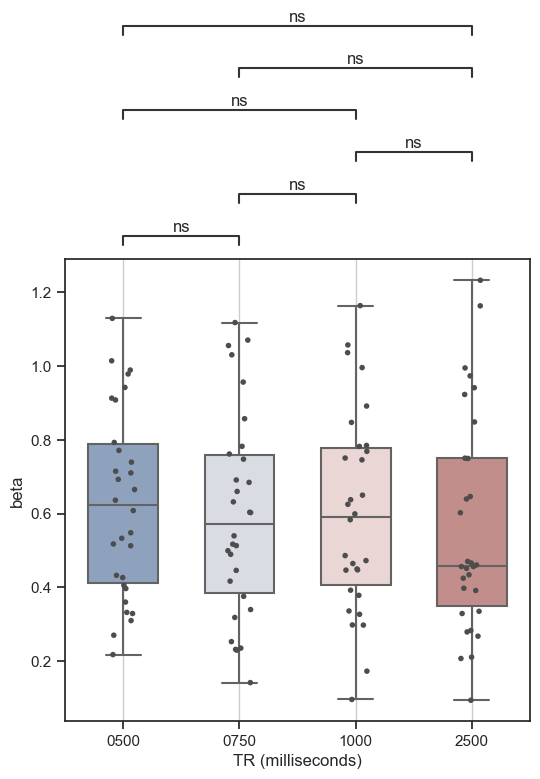

In [35]:
# compare the betas for the different tasks and acquisitions

# Initialize the figure
f, ax = plt.subplots(figsize=(6, 6))

# Plot
sns.boxplot(x="tr", y="beta", data=df,
            width=.6, palette="vlag")

sns.stripplot(x="tr", y="beta", data=df,
              size=4, color=".3", linewidth=0)

ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="beta")

annotator = Annotator(ax, TR_pairs, data=df, x='tr', y='beta', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
annotator.apply_and_annotate()


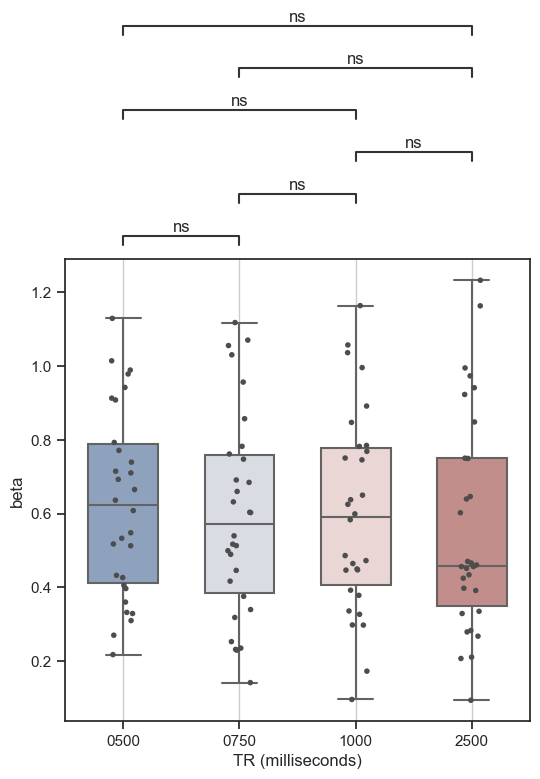

In [36]:
#| label: roi_betas_perTR
f

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0500 vs. 0750: Mann-Whitney-Wilcoxon test two-sided, P_val:7.978e-02 U_stat=5.690e+02
0750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:9.823e-01 U_stat=4.480e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:5.561e-04 U_stat=6.840e+02
0500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided, P_val:6.787e-02 U_stat=5.740e+02
0750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:5.264e-04 U_stat=6.850e+02
0500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided, P_val:1.028e-06 U_stat=7.810e+02


(<Axes: xlabel='TR (milliseconds)', ylabel='t values'>,
  <statannotations.Annotation.Annotation at 0x7f162084dad0>])

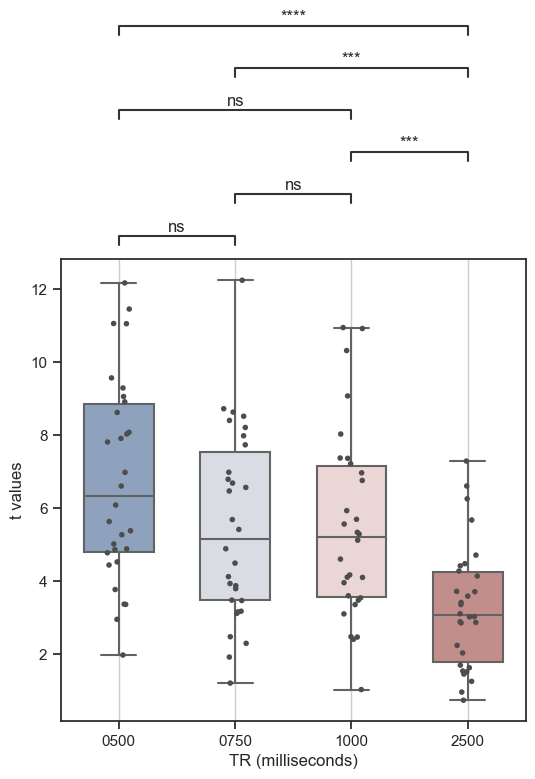

In [37]:
# compare the t values for the different tasks and acquisitions

# Initialize the figure
f, ax = plt.subplots(figsize=(6, 6))

# Plot
sns.boxplot(x="tr", y="tvalue", data=df,
            width=.6, palette="vlag")

sns.stripplot(x="tr", y="tvalue", data=df,
              size=4, color=".3", linewidth=0)

ax.xaxis.grid(True)
ax.set(xlabel="TR (milliseconds)", ylabel="t values")

annotator = Annotator(ax, TR_pairs, data=df, x='tr', y='tvalue', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1)
annotator.apply_and_annotate()


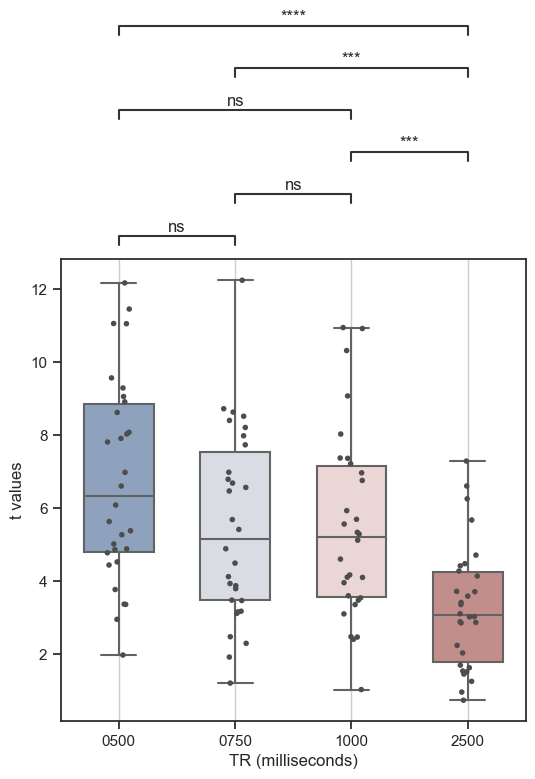

In [38]:
#| label: roi_tvalues_perTR
f